In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from Cluster_characterization import (
    read_cluster_data, plot_all_numeric_means_by_cluster, read_makro, summarize_each_feature_by_cluster,
    read_info, map_cluster_label
)

In [2]:
dataset_cluster = read_cluster_data()

In [3]:
dataset_cluster.set_index("customer_id", inplace=True)

In [4]:
hour_sin_rescaled = dataset_cluster["hour_sin"].clip(-3, 3) / 3
hour_cos_rescaled = dataset_cluster["hour_cos"].clip(-3, 3) / 3

angle = np.arctan2(hour_sin_rescaled, hour_cos_rescaled)  

dataset_cluster["typical_hour"] = (angle * 24 / (2 * np.pi)) % 24

dataset_cluster["typical_hour"] = np.round((angle * 24 / (2 * np.pi)) % 24).astype(int)

In [5]:
dataset_cluster.drop(columns=["hour_sin", "hour_cos"], inplace=True)

In [6]:
dataset_cluster

,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,...,latitude,longitude,age,years_education,years_since_first_transaction,lifetime_spend_techonology,has_loyalty_card,customer_gender,kmeans_cluster,typical_hour
customer_id,,,,,,,,,,,,,,,,,,,,,
29930,1.000000,1.0,0.0,0.500000,-0.375254,0.323394,1.214118,0.567444,1.029630,1.222782,...,-0.758309,0.895939,-0.027101,-0.6,-0.428571,0.632947,0.0,1.0,3,14
6813,-1.000000,0.0,-1.0,0.500000,-0.332876,0.399083,-0.809412,-0.622151,-0.240000,-0.337702,...,-0.382712,-0.187761,0.855364,0.0,0.285714,-0.656762,1.0,0.0,2,16
39451,1.000000,1.0,-1.0,1.500000,0.008118,1.308486,1.256471,1.274336,0.622222,1.300403,...,1.149384,0.281558,-0.600101,-0.6,0.571429,0.326415,0.0,1.0,3,16
16415,0.000000,0.0,0.0,1.000000,1.658394,-0.213303,0.658824,-0.146956,0.118519,0.817540,...,1.114183,0.220402,0.150113,1.4,0.428571,0.042167,1.0,0.0,5,16
22853,0.000000,0.0,0.0,0.000000,0.551196,1.857798,-0.157647,-0.131939,-1.334815,-0.638105,...,0.905467,-0.533152,0.674102,1.4,0.285714,0.103343,1.0,1.0,0,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5653,0.666667,0.5,0.0,0.000000,0.622724,-0.103311,-0.004561,0.748313,0.572626,0.964818,...,0.619942,-0.114588,-0.759096,0.7,-0.777778,-0.184217,1.0,1.0,3,14
164,-0.333333,-0.5,-1.0,-0.333333,-0.088163,-0.433113,0.729761,0.114167,-0.631285,-1.131783,...,0.246971,-0.112381,-0.733782,0.2,-0.222222,-0.131057,1.0,1.0,2,21
26471,-0.333333,0.5,1.0,-0.333333,0.141137,0.511258,-0.015964,0.579139,0.783520,-0.214669,...,0.903840,-0.018910,0.049621,-0.3,1.444444,-0.110103,1.0,1.0,5,6


In [7]:
cluster_col = 'kmeans_cluster'

In [8]:
binary_cols = ['customer_gender', 'has_loyalty_card']

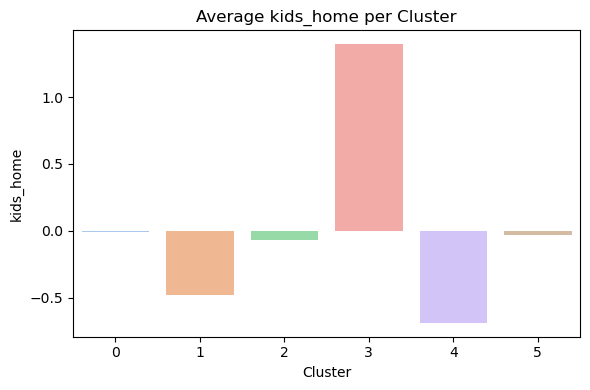

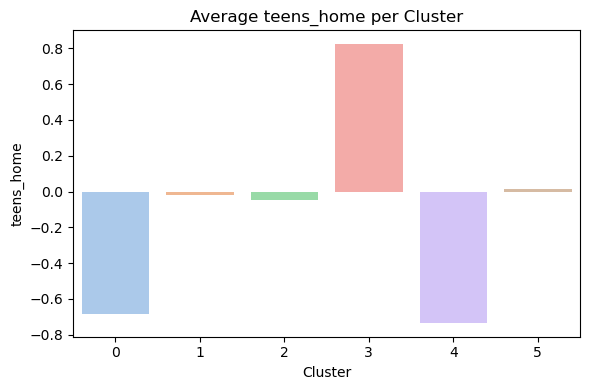

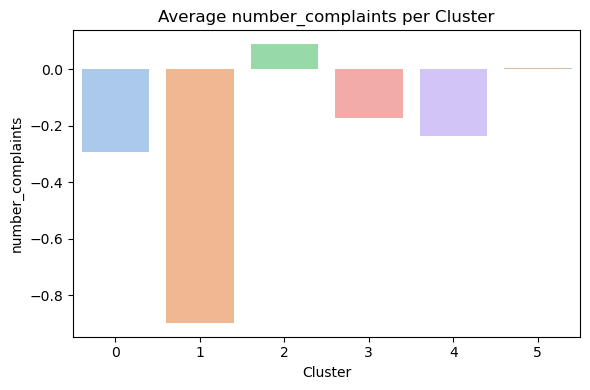

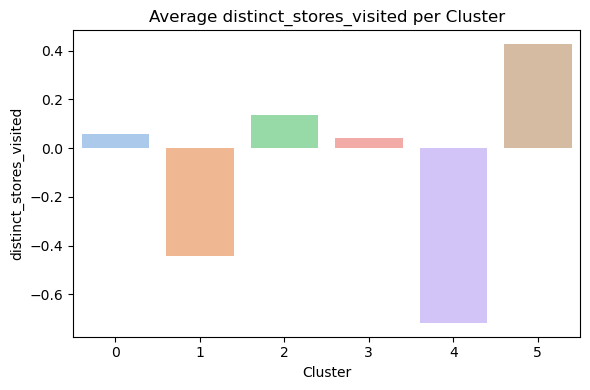

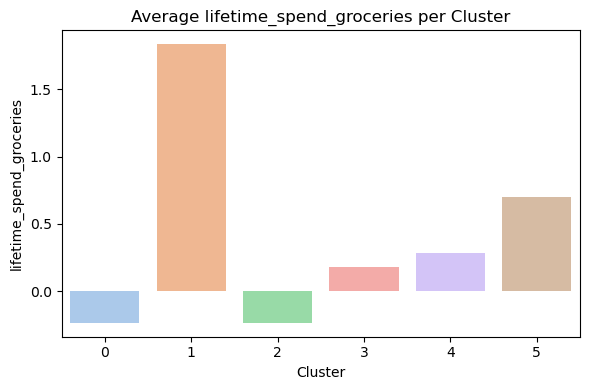

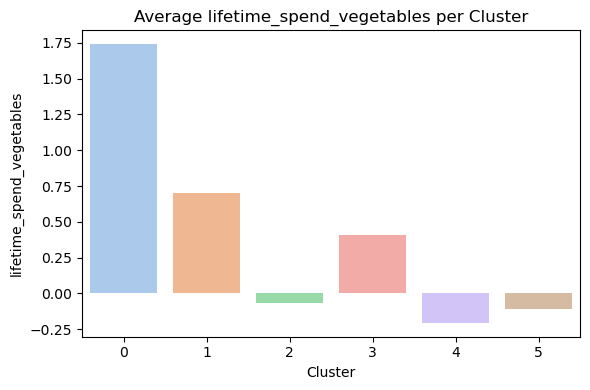

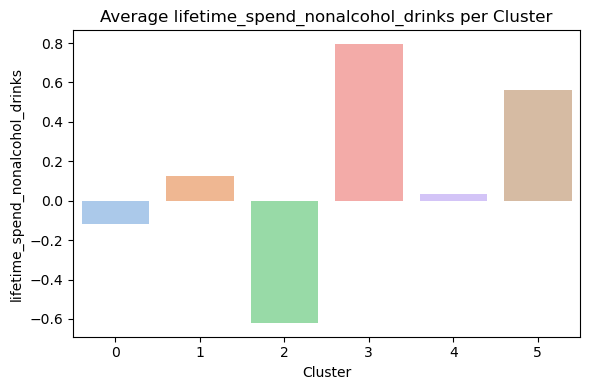

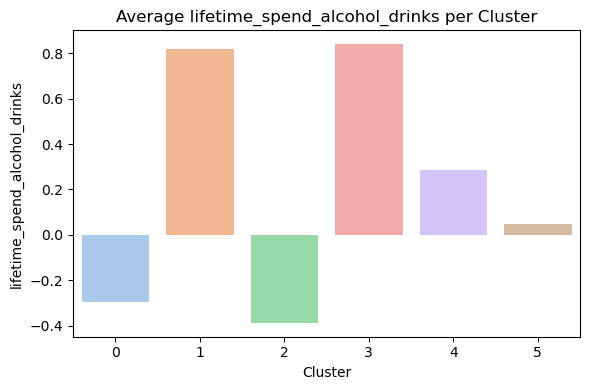

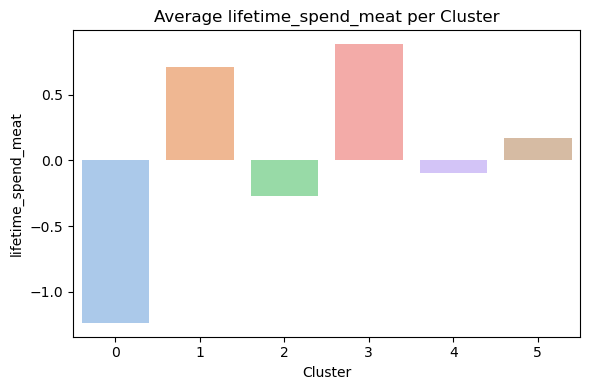

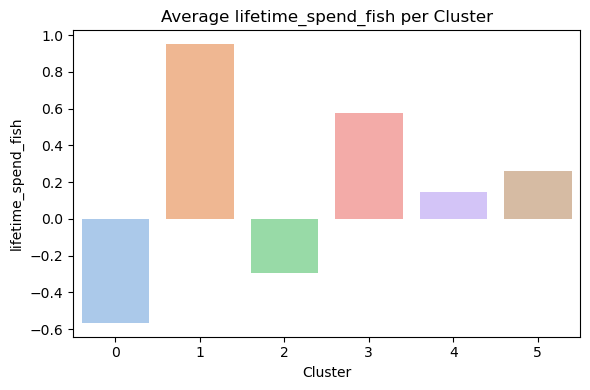

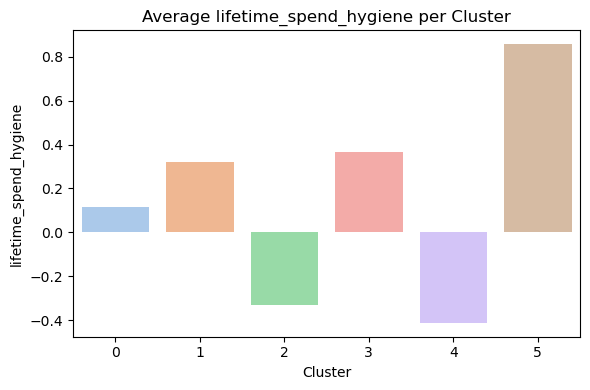

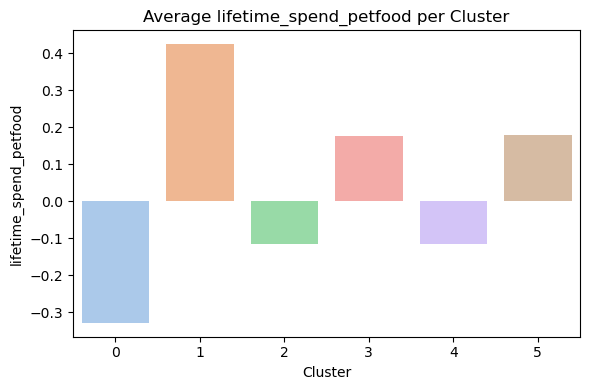

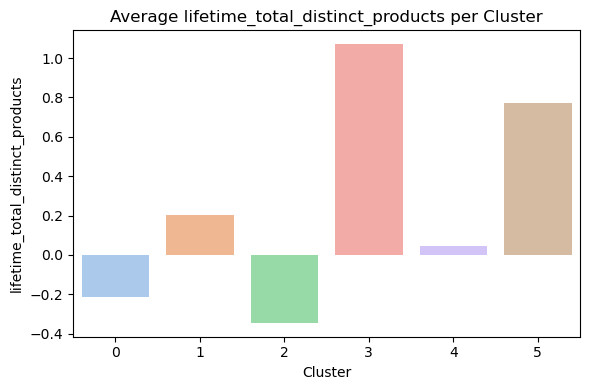

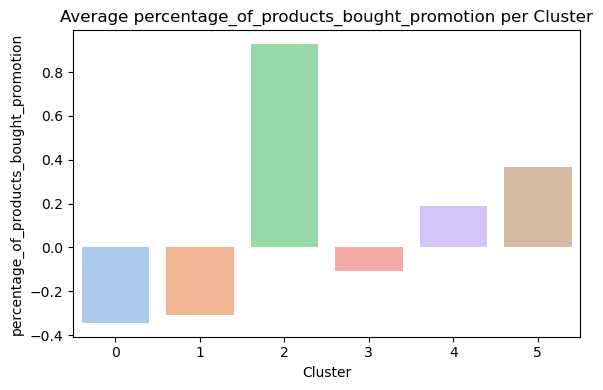

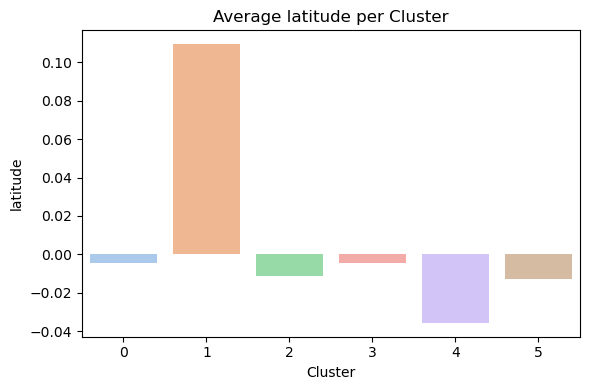

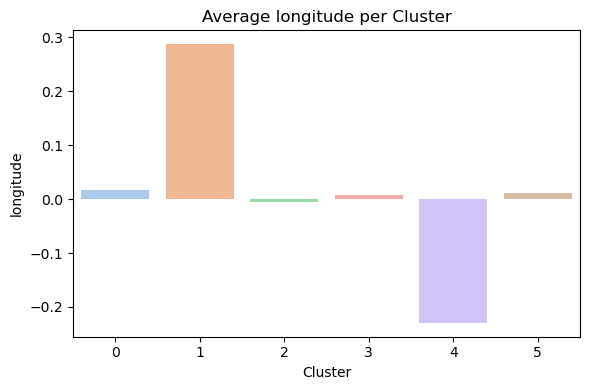

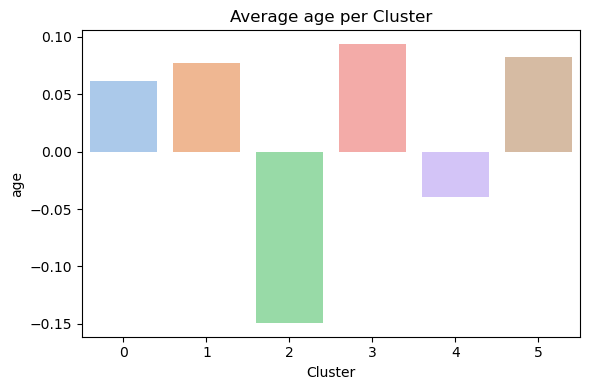

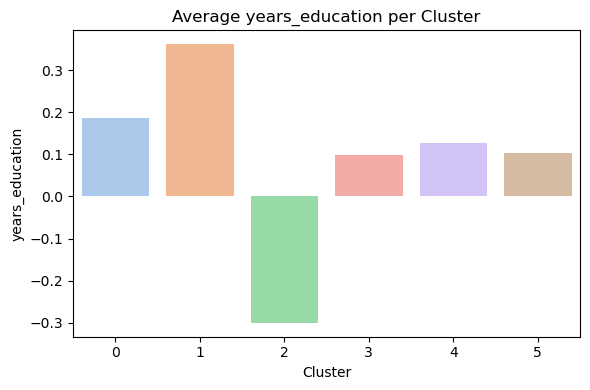

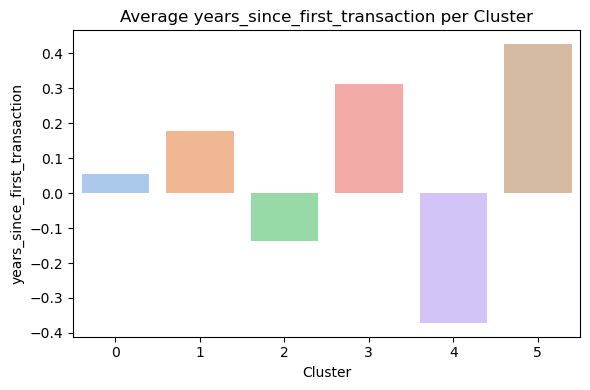

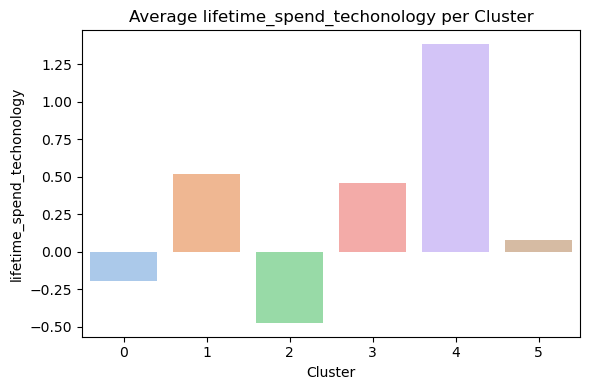

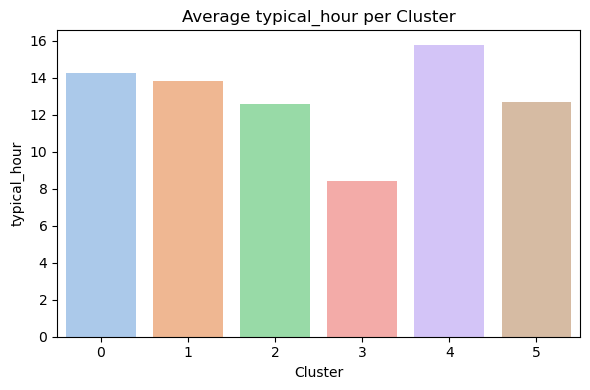

In [9]:
plot_all_numeric_means_by_cluster(dataset_cluster, binary_cols=binary_cols)

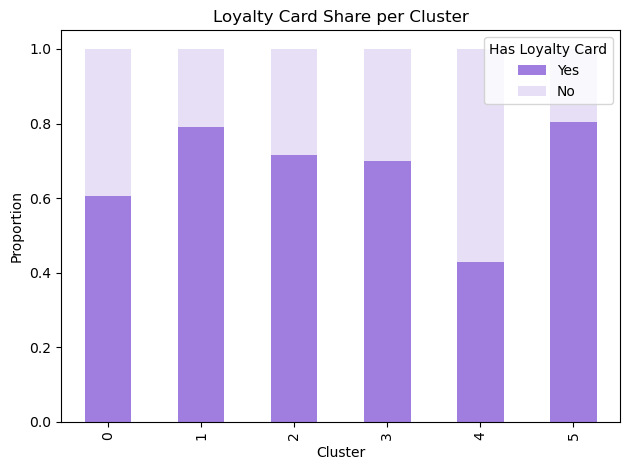

In [10]:
loyalty_pct = (
    dataset_cluster.groupby(cluster_col)["has_loyalty_card"]
    .value_counts(normalize=True)
    .unstack()
)

loyalty_pct = loyalty_pct[[1, 0]]  

custom_colors = ['#a07ee0', '#e6dff5']

loyalty_pct.plot(kind='bar', stacked=True, color=custom_colors)
plt.title("Loyalty Card Share per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.legend(title="Has Loyalty Card", labels=["Yes", "No"])
plt.tight_layout()
plt.show()

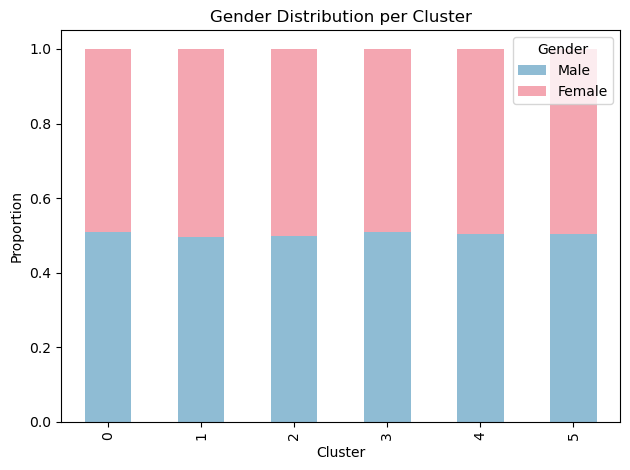

In [11]:
gender_pct = (
    dataset_cluster.groupby(cluster_col)["customer_gender"]
    .value_counts(normalize=True)
    .unstack()
)

gender_pct = gender_pct[[0, 1]] if 0 in gender_pct.columns else gender_pct

custom_colors = ['#8fbcd4', '#f4a6b1']  

gender_pct.plot(
    kind='bar',
    stacked=True,
    color=custom_colors
)

plt.title("Gender Distribution per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.legend(title="Gender", labels=["Male", "Female"])  
plt.tight_layout()
plt.show()

# Makro Cluster Analysis

In [12]:
makro_cluster = read_makro()

In [13]:
makro_cluster["customer_gender"] = makro_cluster["customer_gender"].map({"male": 0, "female": 1})

makro_cluster["has_loyalty_card"] = makro_cluster["loyalty_card_number"].notnull().astype(int)

makro_cluster.drop(columns=["loyalty_card_number"], inplace=True)

In [14]:
makro_cluster

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,latitude,longitude,cluster_alfragide,Cluster,has_loyalty_card
0,38247,Mary Friou,1,05/02/1951 03:13 AM,0.0,0.0,2.0,3.0,53748,8,...,2,12,302,0.072651,2009,38.723945,-9.214207,1,Alfragide,0
1,32615,Craig Whetstone,0,10/10/1995 07:41 AM,0.0,0.0,1.0,1.0,19120,29,...,398,155,345,-0.041897,2019,38.722747,-9.213822,1,Alfragide,0
2,34771,Charlene Sawyer,1,01/11/1977 08:22 PM,0.0,0.0,1.0,2.0,22968,134,...,14,288,418,0.034503,2011,38.722605,-9.213011,1,Alfragide,0
3,36574,Sandra Kittelberger,1,11/01/1947 10:34 AM,0.0,NaN,0.0,2.0,56347,54,...,121,132,753,0.039344,2008,38.724039,-9.213871,1,Alfragide,0
4,39635,John Gibbs,0,10/25/1956 08:30 PM,0.0,0.0,1.0,1.0,16518,177,...,23,122,312,0.137404,2012,38.723436,-9.213355,1,Alfragide,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,9629,Wanda Arocho,1,06/02/1978 09:33 AM,0.0,0.0,1.0,2.0,44968,11,...,363,55,359,0.069041,2010,38.722773,-9.213493,1,Alfragide,0
93,24185,Arthur Monson,0,03/08/1947 02:09 PM,0.0,0.0,1.0,1.0,14943,52,...,186,82,466,0.038034,2013,38.723547,-9.213143,1,Alfragide,0
94,10075,Arthur Meyers,0,07/20/1958 01:35 AM,0.0,0.0,1.0,3.0,8172,18,...,272,224,854,0.012343,2012,38.723378,-9.213280,1,Alfragide,0
95,7703,Angelina Fernandez,1,12/15/1954 01:07 PM,0.0,0.0,1.0,2.0,57503,3,...,148,189,684,0.005066,2010,38.723425,-9.214459,1,Alfragide,0


In [15]:
summarize_each_feature_by_cluster(makro_cluster)


--- Summary for feature: customer_id ---


,Cluster,mean,min,max
0,Alfragide,19372.690722,459,39916



--- Summary for feature: customer_gender ---


,Cluster,mean,min,max
0,Alfragide,0.463918,0,1



--- Summary for feature: kids_home ---


...


--- Summary for feature: cluster_alfragide ---


,Cluster,mean,min,max
0,Alfragide,1.0,1,1



--- Summary for feature: has_loyalty_card ---


,Cluster,mean,min,max
0,Alfragide,0.103093,0,1


{'customer_id':      Cluster          mean  min    max
 0  Alfragide  19372.690722  459  39916,
 'customer_gender':      Cluster      mean  min  max
 0  Alfragide  0.463918    0    1,
 'kids_home':      Cluster  mean  min  max
 0  Alfragide   0.0  0.0  0.0,
 'teens_home':      Cluster  mean  min  max
 0  Alfragide   0.0  0.0  0.0,
 'number_complaints':      Cluster      mean  min  max
 0  Alfragide  0.989583  0.0  2.0,
 'distinct_stores_visited':      Cluster      mean  min  max
 0  Alfragide  1.989362  1.0  3.0,
 'lifetime_spend_groceries':      Cluster          mean   min     max
 0  Alfragide  56427.618557  6774  124466,
 'lifetime_spend_electronics':      Cluster       mean  min  max
 0  Alfragide  82.164948    2  237,
 'typical_hour':      Cluster      mean  min   max
 0  Alfragide  9.234043  6.0  14.0,
 'lifetime_spend_vegetables':      Cluster         mean   min     max
 0  Alfragide  1668.265957  30.0  5380.0,
 'lifetime_spend_nonalcohol_drinks':      Cluster        mean  min  

# Final Cluster Dataset

In [16]:
makro_cluster = makro_cluster.set_index("customer_id")

In [17]:
makro_cluster["Cluster"] = None

In [18]:
makro_cluster.loc[makro_cluster['cluster_alfragide'] == 1, 'Cluster'] = 'Makro Lovers'

In [19]:
makro_cluster = makro_cluster.drop(columns=['cluster_alfragide'])

In [20]:
makro_cluster

,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,...,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,latitude,longitude,Cluster,has_loyalty_card
customer_id,,,,,,,,,,,,,,,,,,,,,
38247,Mary Friou,1,05/02/1951 03:13 AM,0.0,0.0,2.0,3.0,53748,8,11.0,...,892,2,12,302,0.072651,2009,38.723945,-9.214207,Makro Lovers,0
32615,Craig Whetstone,0,10/10/1995 07:41 AM,0.0,0.0,1.0,1.0,19120,29,9.0,...,123,398,155,345,-0.041897,2019,38.722747,-9.213822,Makro Lovers,0
34771,Charlene Sawyer,1,01/11/1977 08:22 PM,0.0,0.0,1.0,2.0,22968,134,9.0,...,434,14,288,418,0.034503,2011,38.722605,-9.213011,Makro Lovers,0
36574,Sandra Kittelberger,1,11/01/1947 10:34 AM,0.0,NaN,0.0,2.0,56347,54,7.0,...,90,121,132,753,0.039344,2008,38.724039,-9.213871,Makro Lovers,0
39635,John Gibbs,0,10/25/1956 08:30 PM,0.0,0.0,1.0,1.0,16518,177,10.0,...,802,23,122,312,0.137404,2012,38.723436,-9.213355,Makro Lovers,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9629,Wanda Arocho,1,06/02/1978 09:33 AM,0.0,0.0,1.0,2.0,44968,11,12.0,...,553,363,55,359,0.069041,2010,38.722773,-9.213493,Makro Lovers,0
24185,Arthur Monson,0,03/08/1947 02:09 PM,0.0,0.0,1.0,1.0,14943,52,8.0,...,351,186,82,466,0.038034,2013,38.723547,-9.213143,Makro Lovers,0
10075,Arthur Meyers,0,07/20/1958 01:35 AM,0.0,0.0,1.0,3.0,8172,18,7.0,...,655,272,224,854,0.012343,2012,38.723378,-9.213280,Makro Lovers,0


In [21]:
dataset_cluster

,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,...,latitude,longitude,age,years_education,years_since_first_transaction,lifetime_spend_techonology,has_loyalty_card,customer_gender,kmeans_cluster,typical_hour
customer_id,,,,,,,,,,,,,,,,,,,,,
29930,1.000000,1.0,0.0,0.500000,-0.375254,0.323394,1.214118,0.567444,1.029630,1.222782,...,-0.758309,0.895939,-0.027101,-0.6,-0.428571,0.632947,0.0,1.0,3,14
6813,-1.000000,0.0,-1.0,0.500000,-0.332876,0.399083,-0.809412,-0.622151,-0.240000,-0.337702,...,-0.382712,-0.187761,0.855364,0.0,0.285714,-0.656762,1.0,0.0,2,16
39451,1.000000,1.0,-1.0,1.500000,0.008118,1.308486,1.256471,1.274336,0.622222,1.300403,...,1.149384,0.281558,-0.600101,-0.6,0.571429,0.326415,0.0,1.0,3,16
16415,0.000000,0.0,0.0,1.000000,1.658394,-0.213303,0.658824,-0.146956,0.118519,0.817540,...,1.114183,0.220402,0.150113,1.4,0.428571,0.042167,1.0,0.0,5,16
22853,0.000000,0.0,0.0,0.000000,0.551196,1.857798,-0.157647,-0.131939,-1.334815,-0.638105,...,0.905467,-0.533152,0.674102,1.4,0.285714,0.103343,1.0,1.0,0,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5653,0.666667,0.5,0.0,0.000000,0.622724,-0.103311,-0.004561,0.748313,0.572626,0.964818,...,0.619942,-0.114588,-0.759096,0.7,-0.777778,-0.184217,1.0,1.0,3,14
164,-0.333333,-0.5,-1.0,-0.333333,-0.088163,-0.433113,0.729761,0.114167,-0.631285,-1.131783,...,0.246971,-0.112381,-0.733782,0.2,-0.222222,-0.131057,1.0,1.0,2,21
26471,-0.333333,0.5,1.0,-0.333333,0.141137,0.511258,-0.015964,0.579139,0.783520,-0.214669,...,0.903840,-0.018910,0.049621,-0.3,1.444444,-0.110103,1.0,1.0,5,6


In [22]:
dataset_cluster = dataset_cluster.rename(columns={"kmeans_cluster": "Cluster"})

In [23]:
final_cluster_dataset_complete = pd.concat([dataset_cluster, makro_cluster], axis=0)

In [24]:
final_cluster_dataset_complete

,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,...,lifetime_spend_techonology,has_loyalty_card,customer_gender,Cluster,typical_hour,customer_name,customer_birthdate,lifetime_spend_electronics,lifetime_spend_videogames,year_first_transaction
customer_id,,,,,,,,,,,,,,,,,,,,,
29930,1.0,1.0,0.0,0.5,-0.375254,0.323394,1.214118,0.567444,1.029630,1.222782,...,0.632947,0.0,1.0,3,14.0,NaN,NaN,NaN,NaN,NaN
6813,-1.0,0.0,-1.0,0.5,-0.332876,0.399083,-0.809412,-0.622151,-0.240000,-0.337702,...,-0.656762,1.0,0.0,2,16.0,NaN,NaN,NaN,NaN,NaN
39451,1.0,1.0,-1.0,1.5,0.008118,1.308486,1.256471,1.274336,0.622222,1.300403,...,0.326415,0.0,1.0,3,16.0,NaN,NaN,NaN,NaN,NaN
16415,0.0,0.0,0.0,1.0,1.658394,-0.213303,0.658824,-0.146956,0.118519,0.817540,...,0.042167,1.0,0.0,5,16.0,NaN,NaN,NaN,NaN,NaN
22853,0.0,0.0,0.0,0.0,0.551196,1.857798,-0.157647,-0.131939,-1.334815,-0.638105,...,0.103343,1.0,1.0,0,22.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9629,0.0,0.0,1.0,2.0,44968.000000,383.000000,894.000000,2257.000000,2185.000000,1827.000000,...,NaN,0.0,1.0,Makro Lovers,12.0,Wanda Arocho,06/02/1978 09:33 AM,11.0,363.0,2010.0
24185,0.0,0.0,1.0,1.0,14943.000000,2346.000000,1051.000000,1234.000000,2271.000000,965.000000,...,NaN,0.0,0.0,Makro Lovers,8.0,Arthur Monson,03/08/1947 02:09 PM,52.0,186.0,2013.0
10075,0.0,0.0,1.0,3.0,8172.000000,305.000000,1153.000000,1748.000000,1899.000000,2379.000000,...,NaN,0.0,0.0,Makro Lovers,7.0,Arthur Meyers,07/20/1958 01:35 AM,18.0,272.0,2012.0


In [25]:
og_dataset = read_info()

In [26]:
missing_id = set(og_dataset["customer_id"]) - set(final_cluster_dataset_complete.index)

if len(missing_id) == 0:
    print("Perfect!")
else:
    print(f"Missing {len(missing_id)} IDs in the final dataset: {missing_id}")

Perfect!


In [27]:
final_cluster_dataset_complete["Cluster"].value_counts()

Cluster
2               9081
5               6011
3               5046
4               4914
0               4630
1               4281
Makro Lovers      97
Name: count, dtype: int64

# Dataset with just ID and Cluster Name

In [28]:
id_and_cluster = final_cluster_dataset_complete["Cluster"]

In [29]:
id_and_cluster

customer_id
29930               3
6813                2
39451               3
16415               5
22853               0
             ...     
9629     Makro Lovers
24185    Makro Lovers
10075    Makro Lovers
7703     Makro Lovers
459      Makro Lovers
Name: Cluster, Length: 34060, dtype: object

In [30]:
id_and_cluster_df = id_and_cluster.reset_index()

In [31]:
id_and_cluster_df.columns = ["customer_id", "Cluster"]

In [32]:
id_and_cluster_df["Cluster"] = id_and_cluster_df['Cluster'].apply(map_cluster_label)

In [33]:
id_and_cluster_df.sort_values(by = "Cluster", inplace=True)

In [34]:
id_and_cluster_df

,customer_id,Cluster
0,29930,Extended Household
14999,2182,Extended Household
3431,23016,Extended Household
3430,12539,Extended Household
15013,2287,Extended Household
...,...,...
22506,27051,Wellness Urbanites
22507,15687,Wellness Urbanites
12726,25726,Wellness Urbanites
3838,38837,Wellness Urbanites


In [35]:
#id_and_cluster_df.to_csv('id_and_cluster.csv', index=True)